# ❒ squarenet: sliding windows
Local views on the grid for fast neigborhood processing

In [1]:
from squarenet import SquareNet
import numpy as np
import matplotlib.pyplot as plt

## Let create a messy point cloud ⛅:

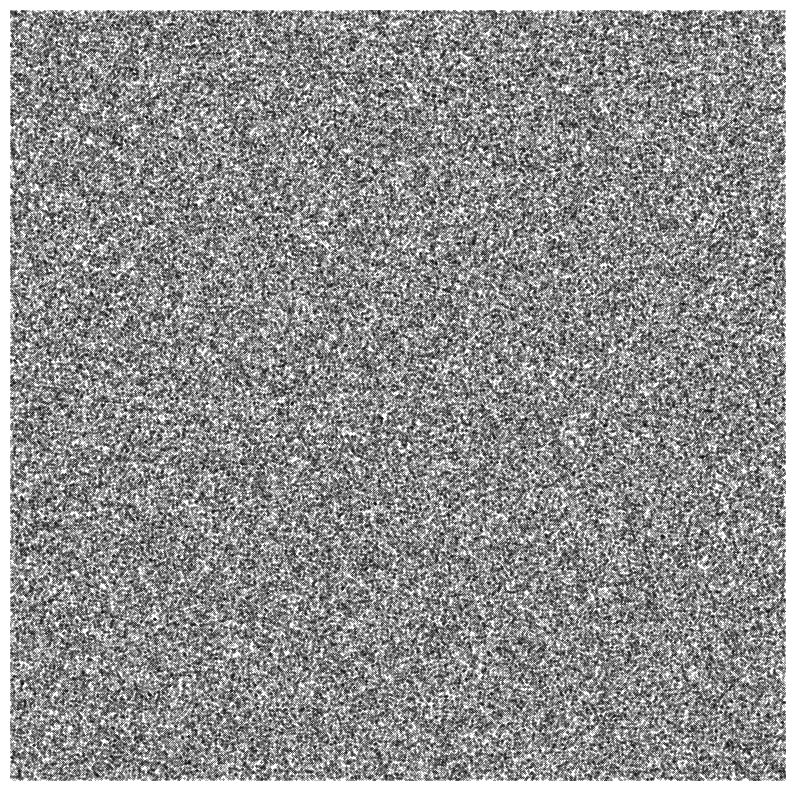

In [2]:
N = 250_000  
D = 2         

points = np.random.rand(N, D)

plt.figure(figsize=(10, 10))
plt.scatter(points[:, 0], points[:, 1], s=0.05, color="black")
plt.axis('off')  
plt.margins(0)   
plt.show()

## We will use a sliding window 🖼️ to compute energy:
- vectorized and O(N) process instead of O(N2)
- -> scales to 250_000 points


I. Fit the Square net:

In [3]:
IJ = (500, 500)
I, J = IJ
sqnet = SquareNet(IJ_=IJ)
sqnet.fit(points)

succesfully sorted at iteration 11


II. Define energy fonction

In [4]:
from squarenet.utils import Potential

In [5]:
def potential_(dist, sigma=0.1):
    s2 = sigma**2
    d2 = np.sum(dist**2, axis=-1)
    return np.exp(- d2/s2)

sigma = 5/1000
potential = Potential(potential_func = potential_, sigma = sigma)
potentialb = Potential(potential_func = potential_, sigma = sigma, batchfirst = True)

Note that we have 250_000 points here. Naive computation of energy is literaly impossible

In [6]:
print("computing energy...")
potential.energy(points) #Fail !

print("One can still compute interaction with subsamples:")
Ns = 20
sample = np.random.choice(N, Ns)
interaction_with_sample = potential.interaction(points, points[sample])

computing energy...
[Crash] failed due to O(N²) complexity | estimated_memory=1000.00 GB | estimated_runtime=125.00 s
One can still compute interaction with subsamples:
[OK] computed in 1.089s


But interaction (here gaussian) is a purely LOCAL phenomenon. 
- It decay rapidly beyond a few σ (in space). 
- As Squarenet.map preseves neighborhood, spatial decay means grid decay. 
- -> So let restrict computation on a local view !
# 🔍


III.Select the window radius

[OK] computed in 0.881s


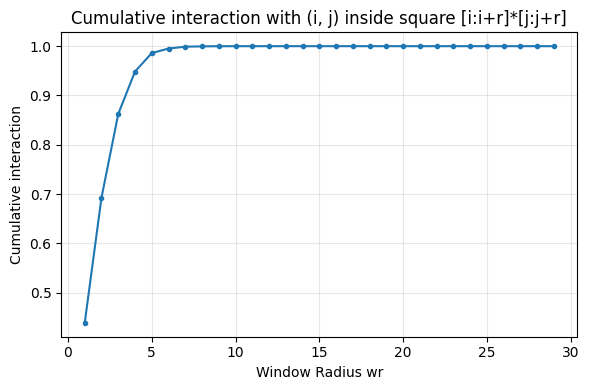

In [7]:
Xmap = sqnet.map(points)

# flatten Xmap to pass it to potential.interaction
Xmapflat = Xmap.reshape(N, 2)
interaction = potential.interaction(Xmapflat, Xmapflat[sample]).reshape(*IJ, Ns)

# center on sampled points. Keep only upright quadrant
interaction_upright = np.zeros((I, J))

for enum, s in enumerate(sample):
    i, j = np.unravel_index(s, shape=IJ)
    upright  = interaction[i:, j:, enum]
    imax, jmax = upright.shape
    interaction_upright[:imax, :jmax] += upright

#Here we use a cumsum trick to estimate energy sums efficiently
energy_ij = interaction_upright.cumsum(axis=-1).cumsum(axis=0)
energy_wr = np.diagonal(energy_ij)[1:30]
energy_wr = energy_wr/energy_wr[-1]
wr = np.arange(1, len(energy_wr)+1) 

plt.figure(figsize=(6, 4))
plt.plot(wr, energy_wr, marker='o', markersize=3)

plt.title("Cumulative interaction with (i, j) inside square [i:i+r]*[j:j+r]")
plt.xlabel("Window Radius wr")
plt.ylabel("Cumulative interaction")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print(f"at wr = 5: {energy_wr[4]:.3f}")

at wr = 5: 0.986


-> By truncating at wr = 5, we will loose roughly 1% of the energy

# Let create a Localview 👁️ with radius 5 !

IV. Local view

In [9]:
wr = 5
ws = 2*wr + 1
Xmap = sqnet.map(points) #(I, J, 2)
X = Xmap.reshape(N, 2)[:, None, :]

Y = sqnet.views(X, wr = wr).reshape(N, 2, ws*ws).transpose(0, 2, 1)
print("view shape:", Y.shape) #(N, ws^2, 2)

view shape: (250000, 121, 2)


# This is the moment of truth ⚖️ - it's make or break.

In [10]:
Interaction = potentialb.interaction(X, Y)
Total_Energy = Interaction.sum()

[OK] computed in 7.316s


🎉 Done! We computed 99% of the energy of the 30 billion pairs of points in a few seconds ⚡

## You just learned ⸽⸽⸽⸽⸽ :
- how to manage fast decaying kernels using Squarenet's view capacity
- how to select a suitable window radius parameter 📡

## Next step ❯❯❯❯ :
- ![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)[ 02_packing_memory.ipynb](https://colab.research.google.com/github/ArmanddeCacqueray/SquareNet/blob/main/exemples/02_packing_memory.ipynb)
- 📦 Pack your dataset for efficient processing  